In [1]:
from sklearn.datasets import load_iris
import pandas as pds
import numpy as npy
import matplotlib.pyplot as plot0411
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
iris = load_iris()
x = pds.DataFrame(iris['data'], columns=iris['feature_names'])
y = pds.DataFrame(iris['target'], columns=['target'])
iris0411 = pds.concat([x,y], axis=1) # 利用concat橫向合併(axis=1直行)
print(iris0411.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [2]:
print("此鳶尾花資料集的數量:", iris0411.shape)
print("鳶尾花資料集col名稱，各別是:", iris0411.keys())
print("鳶尾花資料集之第一個的資料內容:", iris0411.iloc[0,:])
print("鳶尾花資料集之第一個真實值:",iris0411['target'][0])

此鳶尾花資料集的數量: (150, 5)
鳶尾花資料集col名稱，各別是: Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')
鳶尾花資料集之第一個的資料內容: sepal length (cm)    5.1
sepal width (cm)     3.5
petal length (cm)    1.4
petal width (cm)     0.2
target               0.0
Name: 0, dtype: float64
鳶尾花資料集之第一個真實值: 0


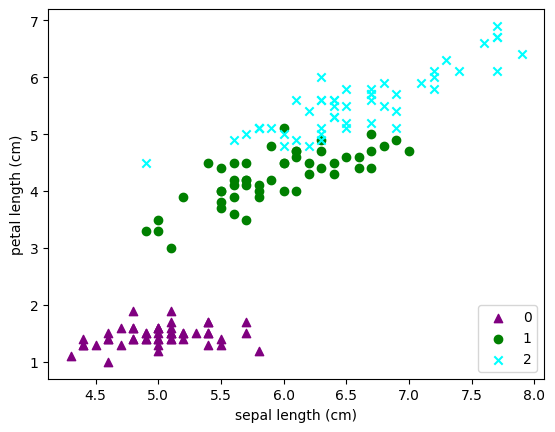

In [3]:
flower_markers = ('^', 'o', 'x')
marker_colors = ('purple', 'green', 'cyan')
#cmap0411 = ListedColormap(marker_colors[:len(npy.unique(y))]) #unique去除重覆元素(花也只有3種)，len找出個數
y = iris0411['target'].values
#print(y)
for i in (npy.unique(y)):  #enumerate將可編列的數據編成序列
    p = iris0411[y == i]
    plot0411.scatter(x=p['sepal length (cm)'],  y=p['petal length (cm)'], c=marker_colors[i], marker=flower_markers[i],  label=i) #scatter散布圖
plot0411.xlabel('sepal length (cm)') #xlabel名稱(萼片)
plot0411.ylabel('petal length (cm)') #ylabel名稱(花瓣)
plot0411.legend(loc='lower right') #標示名稱置放位置右下角
plot0411.show()

In [4]:
iris0411_1 = iris0411[['sepal length (cm)','petal length (cm)','target']]
iris0411_1 = iris0411[iris0411['target'].isin([1,2])]  #在範圍1-2中的資料取出就好，0的不要
print(iris0411_1['target'].value_counts())

1    50
2    50
Name: target, dtype: int64


In [5]:
x_train, x_test, y_train, y_test = train_test_split(iris0411_1[['sepal length (cm)','petal length (cm)']], iris0411_1[['target']], test_size=0.1, random_state=22)
standard_scaler = StandardScaler() #標準化資料
x_train_std = standard_scaler.fit_transform(x_train)
x_test_std = standard_scaler.fit_transform(x_test)
print("鳶尾花訓練資料之訓練集維度大小:   ", x_train_std.shape)
print("鳶尾花測試資料之測試集維度大小:   ", x_test_std.shape)

鳶尾花訓練資料之訓練集維度大小:    (90, 2)
鳶尾花測試資料之測試集維度大小:    (10, 2)


In [6]:
model0411 = LogisticRegression()
model0411.fit(x_train_std, y_train['target'])
print ('係數_Coefficients: ', model0411.coef_)
print ('截距_Intercept: ',model0411.intercept_)

係數_Coefficients:  [[-0.42468279  3.433196  ]]
截距_Intercept:  [0.20434819]


In [7]:
print(model0411.predict(x_test_std))
print(y_test['target'].values)
print(model0411.predict_proba(x_test_std))

[2 1 2 1 1 1 2 1 2 2]
[1 1 2 1 1 1 2 1 2 2]
[[0.38400935 0.61599065]
 [0.90396179 0.09603821]
 [0.01960204 0.98039796]
 [0.97964868 0.02035132]
 [0.79035688 0.20964312]
 [0.94737029 0.05262971]
 [0.03017842 0.96982158]
 [0.94008576 0.05991424]
 [0.11465946 0.88534054]
 [0.00531848 0.99468152]]


In [34]:
confusion_matrix_show = confusion_matrix(y_test['target'],model0411.predict(x_test_std))
print(confusion_matrix_show)

[[10  2]
 [ 0  8]]
